正在生成模拟数据...
开始端到端训练 Transformer + Zuko (可能需要几分钟)...
Epoch   0 | Loss: 2.9293
Epoch 100 | Loss: 2.2110
Epoch 200 | Loss: 1.7154
Epoch 300 | Loss: 1.5027
Epoch 400 | Loss: 1.5891
Epoch 500 | Loss: 1.0369

推断单个被试的参数...


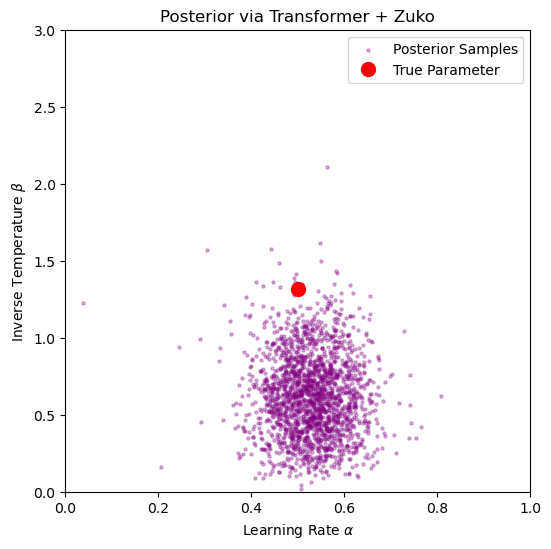

In [ ]:
import torch
import torch.nn as nn
import zuko
import matplotlib.pyplot as plt

# ==========================================
# 1. 强化学习模拟器 (保持不变)
# ==========================================
def simulate_rw_vectorized(theta_raw, rewards_A, rewards_B):
    N = theta_raw.shape[0]
    T = rewards_A.shape[0]
    
    alpha = torch.sigmoid(theta_raw[:, 0])               
    beta = torch.nn.functional.softplus(theta_raw[:, 1]) 
    
    Q = torch.zeros(N, 2)
    choices = torch.zeros(N, T)
    rts = torch.zeros(N, T)
    
    for t in range(T):
        diff = Q[:, 1] - Q[:, 0]
        prob_1 = torch.sigmoid(beta * diff)
        choice = torch.bernoulli(prob_1)
        choices[:, t] = choice
        
        conflict = torch.exp(-torch.abs(diff))
        rt = 0.3 + 0.5 * conflict + torch.randn(N) * 0.05
        rts[:, t] = rt
        
        reward = torch.where(choice == 1, rewards_B[t], rewards_A[t])
        
        idx0 = (choice == 0)
        idx1 = (choice == 1)
        Q[idx0, 0] += alpha[idx0] * (reward[idx0] - Q[idx0, 0])
        Q[idx1, 1] += alpha[idx1] * (reward[idx1] - Q[idx1, 1])
        
    return choices, rts

# ==========================================
# 2. 定义 Transformer 降维网络
# ==========================================
class SequenceSummaryNet(nn.Module):
    def __init__(self, input_dim=2, d_model=32, num_layers=2, output_dim=16, seq_len=100):
        super().__init__()
        # 1. 将 2 维的 (choice, rt) 映射到隐藏层维度 (d_model)
        self.input_proj = nn.Linear(input_dim, d_model)
        
        # 2. 可学习的位置编码 (让模型知道 trial 的先后顺序)
        self.pos_embed = nn.Parameter(torch.randn(1, seq_len, d_model) * 0.02)
        
        # 3. 两层 Transformer 编码器
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=4, dim_feedforward=128, 
            batch_first=True, dropout=0.0
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 4. 最终降维到输出维度 (喂给 Zuko 的 context)
        self.output_proj = nn.Linear(d_model, output_dim)

    def forward(self, x):
        # x shape: (Batch, 100, 2)
        x = self.input_proj(x)                  # (Batch, 100, 32)
        x = x + self.pos_embed                  # 加上位置信息
        x = self.transformer(x)                 # (Batch, 100, 32)
        
        # 全局平均池化：把 100 个 trial 的信息浓缩成一个向量
        x = x.mean(dim=1)                       # (Batch, 32)
        
        x = self.output_proj(x)                 # (Batch, 16)
        return x

# ==========================================
# 3. 生成训练数据 (保留 100 Trials)
# ==========================================
print("正在生成模拟数据...")
N_samples = 15000
T_trials = 100

rewards_A = torch.bernoulli(torch.full((T_trials,), 0.8))
rewards_B = torch.bernoulli(torch.full((T_trials,), 0.2))

theta_raw_prior = torch.randn(N_samples, 2)
sim_choices, sim_rts = simulate_rw_vectorized(theta_raw_prior, rewards_A, rewards_B)

# 【关键改变】：这里不再 view(N, -1) 展平了！保留 (Batch, Seq_len, Features) 的 3D 形状
context_raw = torch.stack([sim_choices, sim_rts], dim=-1) # shape: (15000, 100, 2)
target = theta_raw_prior

# ==========================================
# 4. 联合定义模型与优化器
# ==========================================
# 实例化 Transformer，输出 16 维的浓缩特征
summary_net = SequenceSummaryNet(input_dim=2, output_dim=16, seq_len=100)

# Zuko 接收这 16 维作为 context
flow = zuko.flows.NSF(features=2, context=16, hidden_features=[128, 128])

# 【核心要点】：优化器必须同时包含 Transformer 和 Zuko 的参数，实现端到端训练！
optimizer = torch.optim.Adam(
    list(summary_net.parameters()) + list(flow.parameters()), 
    lr=1e-3
)

epochs = 500 # Transformer 训练稍慢，这里设 500 次先看看效果
batch_size = 1000 # 数据量大，采用 Batch 训练更高效

print("开始端到端训练 Transformer + Zuko (可能需要几分钟)...")
for epoch in range(epochs + 1):
    # 随机打乱并取一个 Batch
    idx = torch.randperm(N_samples)[:batch_size]
    batch_context_raw = context_raw[idx]
    batch_target = target[idx]
    
    optimizer.zero_grad()
    
    # 1. 序列过 Transformer 降维
    batch_summary = summary_net(batch_context_raw)
    
    # 2. 浓缩特征喂给 Zuko 计算 Loss
    loss = -flow(batch_summary).log_prob(batch_target).mean()
    
    loss.backward()
    optimizer.step()
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")



推断单个被试的参数...


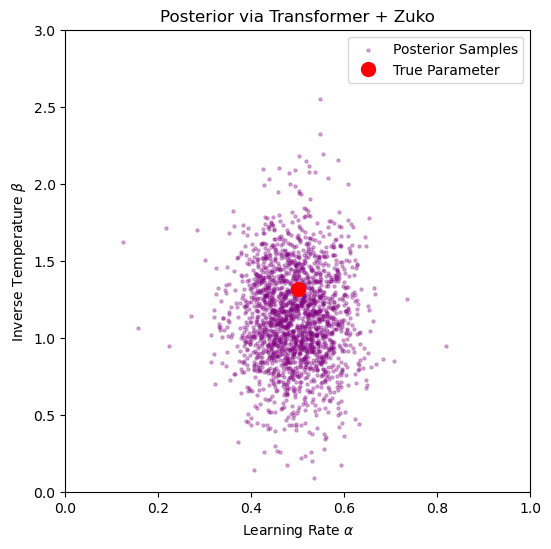

In [19]:
# ==========================================
# 5. 推断真实被试参数
# ==========================================
print("\n推断单个被试的参数...")
true_alpha_raw = torch.tensor([0.0])  # sigmoid(0.0) = 0.5
true_beta_raw = torch.tensor([1.0])   # softplus(1.0) ≈ 1.31
true_theta_raw = torch.tensor([[0.0, 1.0]])

# 生成真实观测数据，并保持 3D 形状 (1, 100, 2)
obs_choices, obs_rts = simulate_rw_vectorized(true_theta_raw, rewards_A, rewards_B)
obs_context_raw = torch.stack([obs_choices, obs_rts], dim=-1)

with torch.no_grad():
    # 推断时，同样先过 Transformer，再过 Zuko
    obs_summary = summary_net(obs_context_raw)
    inferred_thetas_raw = flow(obs_summary).sample((2000,)).squeeze()

# 还原到物理空间
inferred_alpha = torch.sigmoid(inferred_thetas_raw[:, 0]).numpy()
inferred_beta = torch.nn.functional.softplus(inferred_thetas_raw[:, 1]).numpy()
true_alpha_val = torch.sigmoid(true_theta_raw[0, 0]).item()
true_beta_val = torch.nn.functional.softplus(true_theta_raw[0, 1]).item()

plt.figure(figsize=(6, 6))
plt.scatter(inferred_alpha, inferred_beta, s=5, alpha=0.3, label="Posterior Samples", color='purple')
plt.plot(true_alpha_val, true_beta_val, 'ro', markersize=10, label="True Parameter")
plt.xlabel(r"Learning Rate $\alpha$")
plt.ylabel(r"Inverse Temperature $\beta$")
plt.title("Posterior via Transformer + Zuko")
plt.xlim(0, 1); plt.ylim(0, 3)
plt.legend()
plt.show()


=== 开始 Parameter Recovery ===


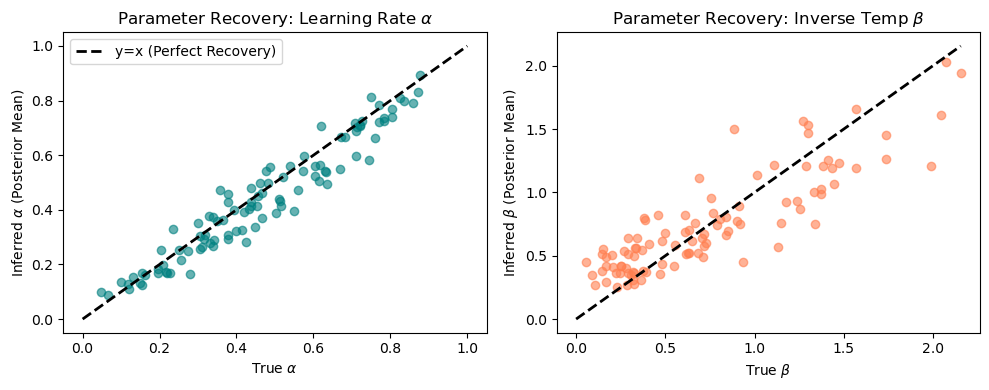

In [13]:
import scipy.stats as stats
import seaborn as sns # 用于画平滑的分布图

# 确保模型在评估模式
summary_net.eval()
flow.eval()

# ==========================================
# 6. Parameter Recovery (参数恢复)
# ==========================================
print("\n=== 开始 Parameter Recovery ===")
N_test = 100 # 测试 100 个全新的虚拟被试

# 1. 随机生成 100 个被试的真实底层参数
test_theta_raw_true = torch.randn(N_test, 2)
# 2. 模拟他们的行为表现
test_choices, test_rts = simulate_rw_vectorized(test_theta_raw_true, rewards_A, rewards_B)
test_context_raw = torch.stack([test_choices, test_rts], dim=-1)

# 3. 记录推断结果的均值
inferred_alpha_means = []
inferred_beta_means = []

true_alphas = torch.sigmoid(test_theta_raw_true[:, 0]).numpy()
true_betas = torch.nn.functional.softplus(test_theta_raw_true[:, 1]).numpy()

with torch.no_grad():
    for i in range(N_test):
        # 逐个推断
        single_obs = test_context_raw[i:i+1]
        summary_feat = summary_net(single_obs)
        
        # 采样 500 个点来代表后验分布
        samples_raw = flow(summary_feat).sample((500,)).squeeze()
        
        # 转换到物理空间并求均值 (作为点估计)
        samples_alpha = torch.sigmoid(samples_raw[:, 0]).numpy()
        samples_beta = torch.nn.functional.softplus(samples_raw[:, 1]).numpy()
        
        inferred_alpha_means.append(samples_alpha.mean())
        inferred_beta_means.append(samples_beta.mean())

# --- 画图：真实值 vs 估计值 ---
plt.figure(figsize=(10, 4))

# Alpha 的恢复情况
plt.subplot(1, 2, 1)
plt.scatter(true_alphas, inferred_alpha_means, alpha=0.6, color='teal')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label="y=x (Perfect Recovery)") 
plt.title(r"Parameter Recovery: Learning Rate $\alpha$")
plt.xlabel(r"True $\alpha$")
plt.ylabel(r"Inferred $\alpha$ (Posterior Mean)")
plt.legend()

# Beta 的恢复情况
plt.subplot(1, 2, 2)
max_beta = max(max(true_betas), max(inferred_beta_means))
plt.scatter(true_betas, inferred_beta_means, alpha=0.6, color='coral')
plt.plot([0, max_beta], [0, max_beta], 'k--', lw=2)
plt.title(r"Parameter Recovery: Inverse Temp $\beta$")
plt.xlabel(r"True $\beta$")
plt.ylabel(r"Inferred $\beta$ (Posterior Mean)")

plt.tight_layout()
plt.show()


=== 开始 Posterior Predictive Check ===


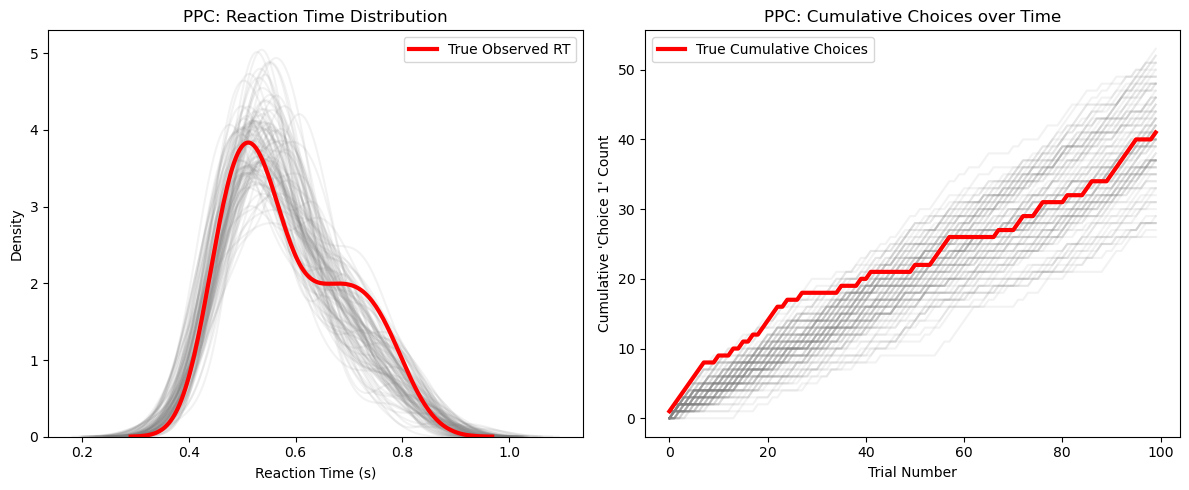

In [14]:
# ==========================================
# 7. Posterior Predictive Check (PPC)
# ==========================================
print("\n=== 开始 Posterior Predictive Check ===")

# 我们使用第 5 步中推断的那个单被试的后验分布: inferred_thetas_raw (shape: 2000, 2)
# 以及他真实的观测数据: obs_choices, obs_rts

# 1. 从后验中随机抽取 100 组参数，代表 100 个基于后验生成的“数字克隆人”
num_ppc_samples = 100
indices = torch.randint(0, inferred_thetas_raw.shape[0], (num_ppc_samples,))
sampled_thetas_raw = inferred_thetas_raw[indices]

# 2. 让这 100 个数字克隆人去玩任务，生成模拟的 Choice 和 RT
ppc_choices, ppc_rts = simulate_rw_vectorized(sampled_thetas_raw, rewards_A, rewards_B)

# 3. 提取真实的被试行为用于对比
true_obs_choices = obs_choices.squeeze().numpy() # shape: (100,)
true_obs_rts = obs_rts.squeeze().numpy()         # shape: (100,)

# --- 画图：模型生成的行为 vs 真实行为 ---
plt.figure(figsize=(12, 5))

# 检查 RT 分布
plt.subplot(1, 2, 1)
for i in range(num_ppc_samples):
    # 画出 100 个数字克隆人的 RT 分布 (半透明灰线)
    sns.kdeplot(ppc_rts[i].numpy(), color='gray', alpha=0.1)
# 画出真实被试的 RT 分布 (红色粗线)
sns.kdeplot(true_obs_rts, color='red', linewidth=3, label='True Observed RT')
plt.title("PPC: Reaction Time Distribution")
plt.xlabel("Reaction Time (s)")
plt.ylabel("Density")
plt.legend()

# 检查 Choice 行为 (累积选择 A 的次数随时间的变化)
plt.subplot(1, 2, 2)
for i in range(num_ppc_samples):
    # 画出数字克隆人的累积选择曲线
    cumulative_choices = ppc_choices[i].numpy().cumsum()
    plt.plot(cumulative_choices, color='gray', alpha=0.1)

# 画出真实被试的累积选择曲线
true_cumulative_choices = true_obs_choices.cumsum()
plt.plot(true_cumulative_choices, color='red', linewidth=3, label='True Cumulative Choices')
plt.title("PPC: Cumulative Choices over Time")
plt.xlabel("Trial Number")
plt.ylabel("Cumulative 'Choice 1' Count")
plt.legend()

plt.tight_layout()
plt.show()